# FAKE REVIEW PREDICTION

Importing Libraries

In [19]:
# Data Handling
import pandas as pd
import numpy as np

# Text Preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Tokenization
from nltk.tokenize import word_tokenize

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

Loading Dataset

In [20]:
import pandas as pd

df = pd.read_csv(r"/content/fake_reviews _dataset.csv")

print(df.shape)
df.head()

(40432, 4)


,category,rating,label,text_
0,Home_and_Kitchen_5,5,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5,CG,Very nice set. Good quality. We have had the s...


Data Cleaning

In [21]:
print(df.isnull().sum())
df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())
df.shape

category    0
rating      0
label       0
text_       0
dtype: int64
0


(40420, 4)

Label Classification Counts:
 label
OR    20215
CG    20205
Name: count, dtype: int64

0 = Manual Review, 1 = LLM Generated Review


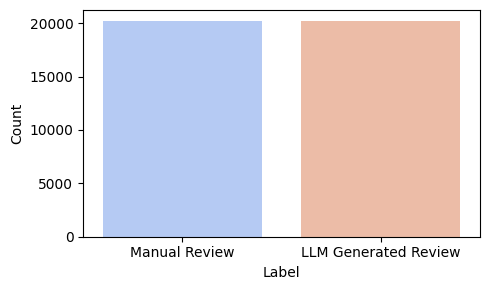

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Print value counts
label_counts = df['label'].value_counts()
print("Label Classification Counts:\n", label_counts)
print("\n0 = Manual Review, 1 = LLM Generated Review")

# Plot
plt.figure(figsize=(5,3))
sns.countplot(x='label', data=df,palette='coolwarm',legend=False,hue='label')

plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Manual Review', 'LLM Generated Review'])
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
# Basic text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Full preprocessing
def preprocess_text(text):
    text = clean_text(text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_text'] = df['text_'].astype(str).apply(preprocess_text)
df[['text_', 'cleaned_text']].head()

# Check for nulls in each column
df.isnull().sum()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,0
category,0
rating,0
label,0
text_,0
cleaned_text,0


In [24]:
# Calculate character length of each review
df['char_length'] = df['cleaned_text'].apply(len)
df[['cleaned_text', 'char_length']].head()

,cleaned_text,char_length
0,love well made sturdy comfortable love itvery ...,52
1,love great upgrade original ive mine couple year,48
2,pillow saved back love look feel pillow,39
3,missing information use great product price,43
4,nice set good quality set two month,35


Handling Text Length Outliers

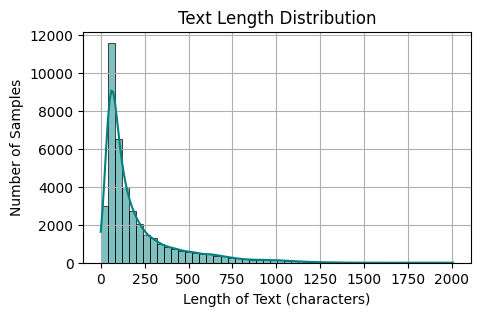

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['cleaned_text'] = df['cleaned_text'].astype(str)

#Text Length Distribution
df['text_length'] = df['cleaned_text'].apply(len)

plt.figure(figsize=(5,3))
sns.histplot(df['text_length'], bins=50, kde=True, color='teal')
plt.title('Text Length Distribution')
plt.xlabel('Length of Text (characters)')
plt.ylabel('Number of Samples')
plt.grid(True)
plt.show()

After Capping

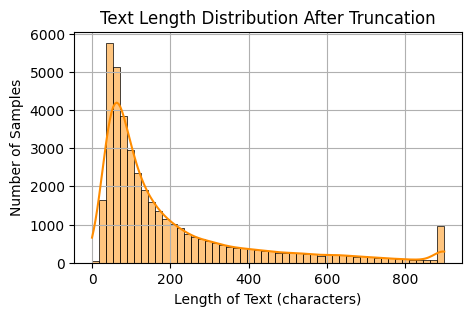

In [26]:
# Truncate Text to 900 Characters
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: x[:900] if len(x) > 900 else x)

# Recalculate text length
df['text_length'] = df['cleaned_text'].apply(len)

#Truncated Text Length Distribution
plt.figure(figsize=(5,3))
sns.histplot(df['text_length'], bins=50, kde=True, color='darkorange')
plt.title('Text Length Distribution After Truncation')
plt.xlabel('Length of Text (characters)')
plt.ylabel('Number of Samples')
plt.grid(True)
plt.show()

Label Encoding

In [27]:
# Label encode:
df['label_encoded'] = df['label'].apply(lambda x: 1 if x == 'CG' else 0)
df[['label', 'label_encoded']].value_counts()

,,count
label,label_encoded,
OR,0,20215
CG,1,20205


Word Clouds

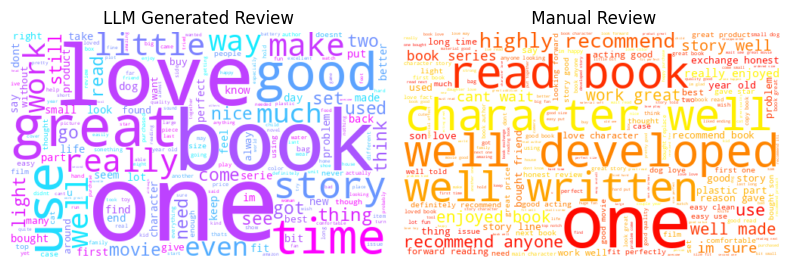

In [28]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Define STOPWORDS
stopwords = set(STOPWORDS)

# Separate the texts
llm_text = ' '.join(df[df['label_encoded'] == 0]['cleaned_text'])
manual_text = ' '.join(df[df['label_encoded'] == 1]['cleaned_text'])

# Generate word clouds
wordcloud_llm = WordCloud(width=500, height=300, background_color='white',
                          stopwords=stopwords, colormap='cool').generate(llm_text)

wordcloud_manual = WordCloud(width=500, height=300, background_color='white',
                             stopwords=stopwords, colormap='autumn').generate(manual_text)

# Plot
plt.figure(figsize=(8,5))

# LLM Generated Review
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_llm, interpolation='bilinear')
plt.axis('off')
plt.title("LLM Generated Review")

# Manual Review
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_manual, interpolation='bilinear')
plt.axis('off')
plt.title(" Manual Review")
plt.tight_layout()
plt.show()

Handling Text Length Outliers

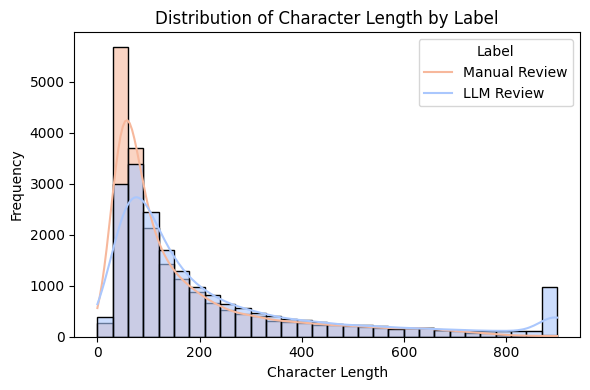

In [29]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='text_length', hue='label_encoded', bins=30, kde=True, palette='coolwarm', alpha=0.6)
plt.title('Distribution of Character Length by Label')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.legend(title='Label', labels=['Manual Review', 'LLM Review'])
plt.tight_layout()
plt.show()

Vectorization

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into numerical features
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['label_encoded']

# Logistic Regression

Logistic Regression Performance
Accuracy  : 0.8376
Precision : 0.8359
Recall    : 0.8414
F1-Score  : 0.8386

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.84      4029
           1       0.84      0.84      0.84      4055

    accuracy                           0.84      8084
   macro avg       0.84      0.84      0.84      8084
weighted avg       0.84      0.84      0.84      8084



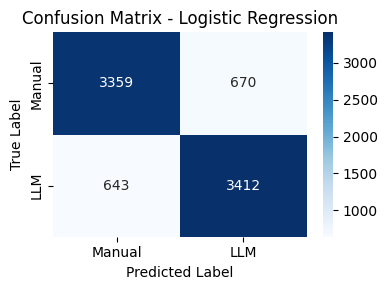

In [31]:
#LOGISTIC REGRESSION
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

#Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

#Make predictions
y_pred = lr_model.predict(X_test)

#Evaluate the model
acc_lr = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance")
print(f"Accuracy  : {acc_lr:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Manual', 'LLM'], yticklabels=['Manual', 'LLM'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

# XGBoost

XGBoost Classifier Performance
Accuracy  : 0.8350
Precision : 0.8491
Recall    : 0.8160
F1-Score  : 0.8322

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84      4029
           1       0.85      0.82      0.83      4055

    accuracy                           0.83      8084
   macro avg       0.84      0.84      0.83      8084
weighted avg       0.84      0.83      0.83      8084



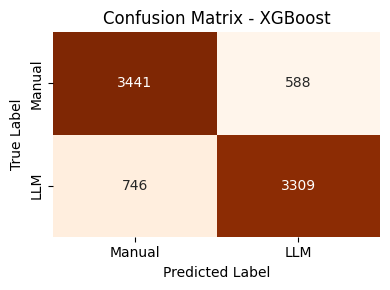

In [32]:
# XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train XGBoost model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
acc_xgb = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("XGBoost Classifier Performance")
print(f"Accuracy  : {acc_xgb:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Manual', 'LLM'], yticklabels=['Manual', 'LLM'], cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

# Light GBM

LightGBM Classifier Performance
Accuracy  : 0.8389
Precision : 0.8420
Recall    : 0.8358
F1-Score  : 0.8389

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      4029
           1       0.84      0.84      0.84      4055

    accuracy                           0.84      8084
   macro avg       0.84      0.84      0.84      8084
weighted avg       0.84      0.84      0.84      8084



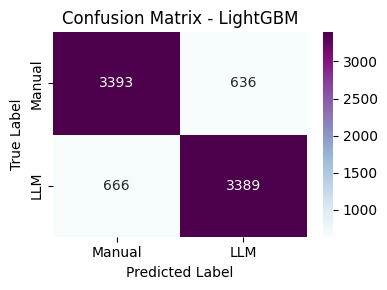

In [33]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
# Train the LightGBM model
lgbm_model = LGBMClassifier(random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)

# Make predictions
y_pred = lgbm_model.predict(X_test)

# Evaluate the model
acc_lgbm = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("LightGBM Classifier Performance")
print(f"Accuracy  : {acc_lgbm:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='BuPu',
            xticklabels=['Manual', 'LLM'], yticklabels=['Manual', 'LLM'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LightGBM")
plt.tight_layout()
plt.show()

# LSTM

Epoch 1/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6745 - loss: 0.5836 - val_accuracy: 0.8568 - val_loss: 0.3256
Epoch 2/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8506 - loss: 0.3516 - val_accuracy: 0.8726 - val_loss: 0.2987
Epoch 3/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8648 - loss: 0.3176 - val_accuracy: 0.8751 - val_loss: 0.2941
Epoch 4/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8758 - loss: 0.2941 - val_accuracy: 0.8760 - val_loss: 0.2839
Epoch 5/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8823 - loss: 0.2798 - val_accuracy: 0.8831 - val_loss: 0.2804
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Model Performance
Accuracy  : 0.8824
Precision : 0.9095
Recall    : 0.8501
F1-Score  : 0.8788

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.89      4029
           1       0.91      0.85      0.88      4055

    accuracy                        

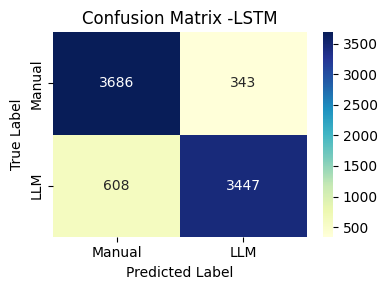

In [34]:
#LSTM
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tokenization and padding
tokenizer = Tokenizer(num_words=2000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
padded_sequences = pad_sequences(sequences, maxlen=100)

# Labels
y = df['label_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)

# Smaller and shallower LSTM model
model = Sequential([
    Embedding(input_dim=1000, output_dim=16, input_length=80),
    LSTM(16, return_sequences=False),
    Dropout(0.8),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fewer epochs and larger batch size
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)
acc_lstm = accuracy_score(y_test, y_pred)

# Evaluation
acc_lstm = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("LSTM Model Performance")
print(f"Accuracy  : {acc_lstm:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Manual', 'LLM'], yticklabels=['Manual', 'LLM'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix -LSTM")
plt.tight_layout()
plt.show()

# GRU

Epoch 1/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7108 - loss: 0.5716 - val_accuracy: 0.8423 - val_loss: 0.3610
Epoch 2/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8484 - loss: 0.3760 - val_accuracy: 0.8701 - val_loss: 0.3023
Epoch 3/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8783 - loss: 0.3030 - val_accuracy: 0.8828 - val_loss: 0.2692
Epoch 4/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8932 - loss: 0.2729 - val_accuracy: 0.8912 - val_loss: 0.2620
Epoch 5/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9006 - loss: 0.2545 - val_accuracy: 0.8924 - val_loss: 0.2657
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
GRU Model Performance
Accuracy  : 0.8894
Precision : 0.8791
Recall    : 0.9038
F1-Score  : 0.8913

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      4029
           1       0.88      0.90      0.89      4055

    accuracy                        

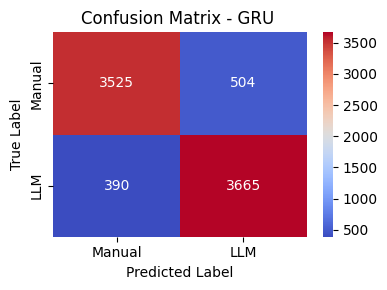

In [35]:
#GRU
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import tensorflow as tf

# Tokenization and padding
tokenizer = Tokenizer(num_words=2000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
padded_sequences = pad_sequences(sequences, maxlen=100)

# Labels
y = df['label_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)

# GRU model
model = Sequential([
    Embedding(input_dim=2000, output_dim=32, input_length=100),
    GRU(16, return_sequences=False),
    Dropout(0.8),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Evaluation
acc_gru = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("GRU Model Performance")
print(f"Accuracy  : {acc_gru:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Manual', 'LLM'], yticklabels=['Manual', 'LLM'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - GRU ")
plt.tight_layout()
plt.show()

# CNN+Bi-GRU


Epoch 1/8
910/910 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.8060 - loss: 0.3826 - val_accuracy: 0.9075 - val_loss: 0.2101
Epoch 2/8
910/910 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9405 - loss: 0.1482 - val_accuracy: 0.9128 - val_loss: 0.2148
Epoch 3/8
910/910 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9716 - loss: 0.0757 - val_accuracy: 0.9051 - val_loss: 0.3018
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
CNN + Bi-GRU Model Performance
Accuracy  : 0.9086
Precision : 0.9076
Recall    : 0.9105
F1-Score  : 0.9090

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      4029
           1       0.91      0.91      0.91      4055

    accuracy                           0.91      8084
   macro avg       0.91      0.91      0.91      8084
weighted avg       0.91      0.91      0.91      8084



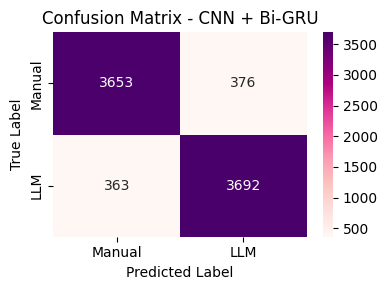

In [37]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tokenization and sequence padding
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
padded_sequences = pad_sequences(sequences, maxlen=250)

# Prepare train-test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, df['label_encoded'], test_size=0.2, random_state=42)

# Define CNN + Bi-GRU model
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=250),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Bidirectional(GRU(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Early stopping
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train and capture the history
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)

# Predict and evaluate
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

acc_cbg = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("CNN + Bi-GRU Model Performance")
print(f"Accuracy  : {acc_cbg:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Manual', 'LLM'], yticklabels=['Manual', 'LLM'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN + Bi-GRU")
plt.tight_layout()
plt.show()

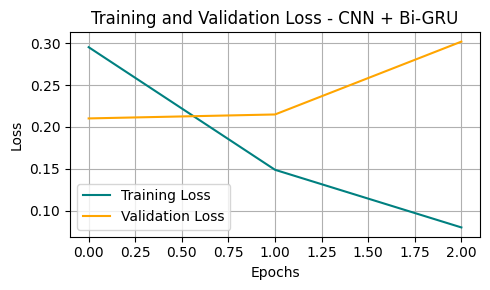

In [38]:
# Plot Training and Validation Loss
plt.figure(figsize=(5,3))
plt.plot(history.history['loss'], label='Training Loss', color='teal')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Training and Validation Loss - CNN + Bi-GRU")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Model-wise Accuracy Comparison

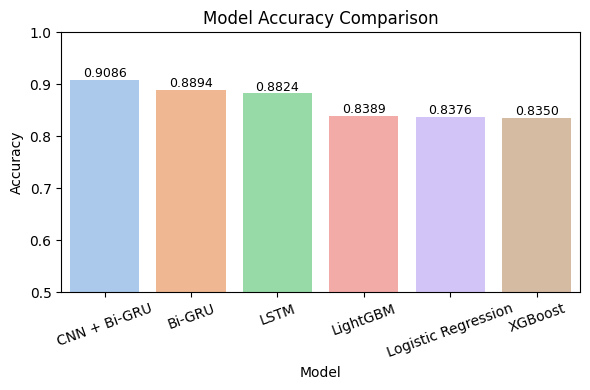

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define all model accuracies
model_performance = pd.DataFrame({
    'Model': ['CNN + Bi-GRU', 'Bi-GRU', 'LSTM', 'LightGBM', 'Logistic Regression', 'XGBoost'],
    'Accuracy': [acc_cbg, acc_gru, acc_lstm, acc_lgbm, acc_lr, acc_xgb]
})

# Sort by accuracy for better visual clarity
model_performance = model_performance.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=model_performance, x='Model', y='Accuracy', palette='pastel')

# Add accuracy labels on top of bars
for i, row in model_performance.iterrows():
    plt.text(i, row['Accuracy'] + 0.005, f"{row['Accuracy']:.4f}", ha='center', fontsize=9)

# Formatting
plt.ylim(0.5, 1.0)
plt.xticks(rotation=20)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()